In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

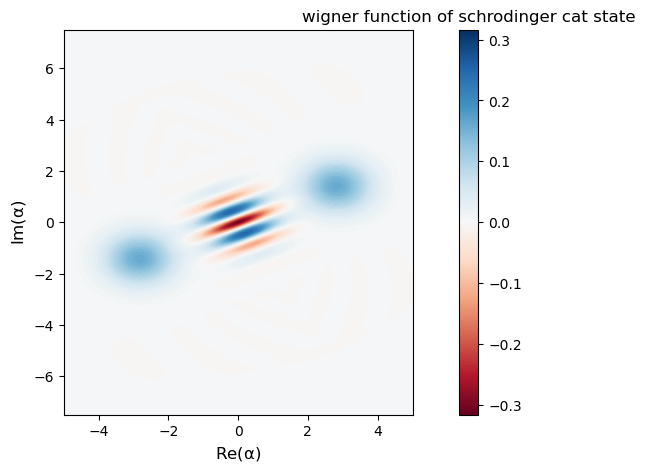

In [3]:
alpha = 2.0 + 1.0j
N = 20

#schrodinger cat state
coh1 = coherent(N, alpha)
coh2 = coherent(N, -alpha)
cat = coh1 - coh2
cat = cat.unit()

#wigner function
x = np.linspace(-5, 5, 500)
w = wigner(cat, x, x)

fig, axe = plt.subplots(figsize=(6,5))
plot_wigner(cat, x, ax=axe, colorbar=True)
plt.title("wigner function of schrodinger cat state")
plt.show()

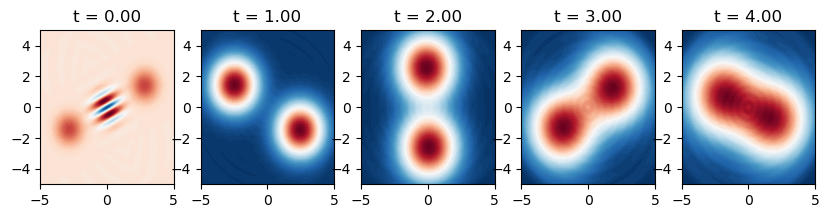

In [19]:
N = 20
alpha = 2.0+1.0j

omega = 1
gamma = 0.1
n_th = 5

a = destroy(N)
H = omega * a.dag() * a

#collapse operators
c1 = np.sqrt(2 * gamma * (n_th+1)) * a  #cavity dissipation
c2 = np.sqrt(2 * gamma * n_th) * a.dag()  #cavity excitation
c_ops = [c1, c2]

#density matrix
rho = ket2dm(cat)

#time evolution
time = np.linspace(0, 5, 51)
result = mesolve(H, rho, time, c_ops, [])

#wigner functions, at each time step
x = np.linspace(-5, 5, 500)
wigner_data = [wigner(psi, x, x) for psi in result.states]

fig, axe = plt.subplots(1,5, figsize=(10, 2))
for i in range(0,5):
    w_plot = axe[i].contourf(x, x, wigner_data[10*i], 100, cmap='RdBu_r')
    title = axe[i].set_title(f"t = {time[10*i]:.2f}")


E:\Anaconda\envs\qutip-env\lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


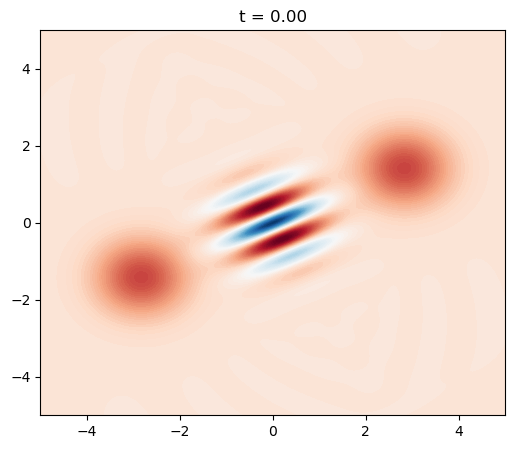

In [20]:
from matplotlib.animation import FuncAnimation

fig, axe = plt.subplots(figsize=(6, 5))
wigner_data = [wigner(rho, x, x) for rho in result.states]
w_plot = axe.contourf(x, x, wigner_data[0], 100, cmap='RdBu_r')
title = axe.set_title(f"t = {time[0]:.2f}")

def update(frame):
    global w_plot
    for c in w_plot.collections:
        c.remove()
    w_plot = axe.contourf(x, x, wigner_data[frame], 100, cmap='RdBu_r')
    title.set_text(f"t = {time[frame]:.2f}")
    return w_plot

ani = FuncAnimation(fig, update, frames=len(time), blit=False)
plt.show()

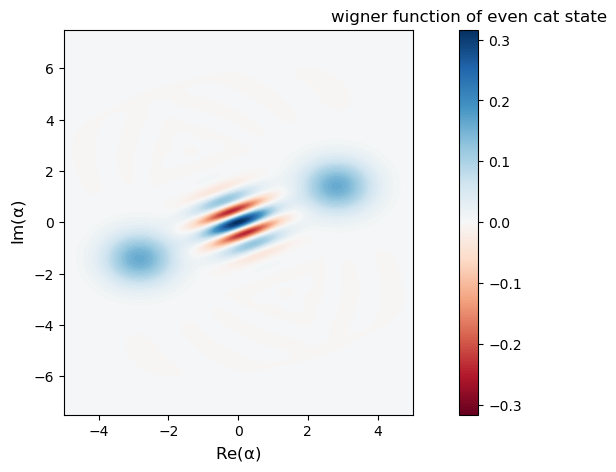

In [24]:
#even cat state
cat_even = coh1 + coh2
cat_even = cat1.unit()

x = np.linspace(-5, 5, 500)
w1 = wigner(cat_even, x, x)

fig, axe = plt.subplots(figsize=(6,5))
plot_wigner(cat_even, x, ax=axe, colorbar=True)
plt.title("wigner function of even cat state")
plt.show()

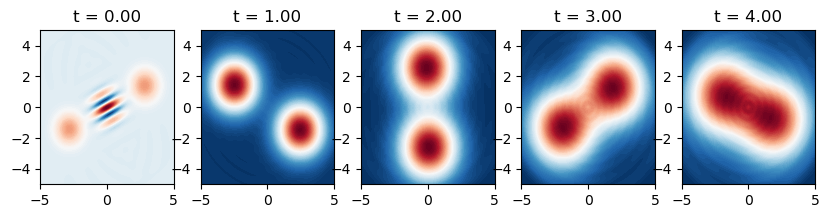

In [23]:
#density matrix
rho_even = ket2dm(cat_even)

#time evolution
time = np.linspace(0, 5, 51)
result_even = mesolve(H, rho_even, time, c_ops, [])

#wigner functions, at each time step
x = np.linspace(-5, 5, 500)
wigner_data_even = [wigner(psi, x, x) for psi in result_even.states]

fig, axe = plt.subplots(1,5, figsize=(10, 2))
for i in range(0,5):
    w_plot_even = axe[i].contourf(x, x, wigner_data_even[10*i], 100, cmap='RdBu_r')
    title = axe[i].set_title(f"t = {time[10*i]:.2f}")